# Midpoint continuations without the learned price-level reset

The previous correction trained only 16 future events. Forecasting then kept
feeding a growing Wiener path into the generator for over 40,000 events.
Resetting that noise helps, but the price-level model still has deterministic
drift. Return models remove absolute price as an input, yet even a small
learned return bias accumulates in a long forecast.

The recommended variant uses **anchored price innovations**. TimeGAN generates
book structure; a separate neural head estimates return volatility from past
book features. Expected price drift is fixed to the empirical **training-data**
drift. Gaussian innovations have stationary per-event variance. The lognormal
correction keeps expected arithmetic-price changes at that calibrated drift.
Prices accumulate from the last observed midpoint. The decoder cannot move
prices towards an absolute learned level in this variant.

This is an explicit **hybrid model**, with a fixed drift assumption. It does
not learn directional price signals. The volatility head is fitted for 1,000
updates on training prefixes and their real 16-event futures, with TimeGAN
frozen. The two return TimeGANs use seed 0, the original architecture and
1,000/1,000/5,000 stage budgets, D rate 1e-4, and G/E/R rates 3e-4. They add
return mean/SD matching (weight 10) and cumulative-return context supervision
(weights 1 and 10). Their outputs remain as controls for residual learned bias.

Forecasts use 48 history events and 16 generated events per block. After the
initial real prefix, every conditioning event is generated; no future real
validation observations enter a continuation. The old price-level controls
retain their original 64-event starting context. Noise-reset control changes
only the noise clock and retains the same checkpoint as the old model.

The first chart shows the recommended variant. Later charts show the controls.
Full charts include each case's entire price range; early zooms share a common
scale. Bands are completion SD, not confidence intervals. One training seed
and one day do not establish calibrated uncertainty or realistic joint book
dynamics. The systematic price-level reset is the specific problem addressed.


In [1]:
from pathlib import Path
import sys
import json

project_dir = next(
    (directory for directory in (Path.cwd(), *Path.cwd().parents)
     if (directory / "dataset.py").exists()),
    None,
)
if project_dir is None:
    raise FileNotFoundError("Launch from the recognition project.")
sys.path.insert(0, str(project_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from dataset import LOBSTERLevel10Dataset

RESULTS_DIR = project_dir / "runs" / "return_price"
EXPERIMENTS = ["innovation_head", "previous_levels", "reset_noise", "returns_context_1_moments_10", "returns_context_10_moments_10"]
LABELS = {"innovation_head": "Calibrated price innovations (recommended)",
          "previous_levels": "Previous correction: price levels",
          "reset_noise": "Price levels: noise reset alone",
          "returns_context_1_moments_10": "Return model: context weight 1",
          "returns_context_10_moments_10": "Return model: context weight 10"}
(RESULTS_DIR / "figures").mkdir(exist_ok=True)


In [2]:
results = {}
summary_rows = []
snapshot_rows = []
for name in EXPERIMENTS:
    directory = RESULTS_DIR / f"{name}_seed_0"
    metadata = json.loads((directory / "run.json").read_text())
    step = metadata["training_config"]["joint_steps"]
    diagnostic = json.loads((directory / "diagnostics_final.json").read_text())
    with np.load(directory / "completion_midpoints.npz") as archive:
        full_curves = {key: archive[key].copy() for key in archive.files}
    history = pd.read_csv(directory / "losses.csv")
    final_losses = history.loc[history["stage"] == "joint"].tail(100)
    results[name] = {
        "metadata": metadata, "diagnostic": diagnostic, "full": full_curves,
        "contexts": pd.read_csv(directory / "contexts_final.csv"),
    }
    summary_rows.append({
        "experiment": LABELS[name],
        **diagnostic["metrics"],
        "boundary_peak_mean_rise_64_dollars": max(0.0, max(diagnostic["curves"]["generated_mean"][:64])
                                                    - diagnostic["curves"]["starting_price_dollars"]),
        "boundary_max_mean_abs_error_64_dollars": float(np.max(np.abs(
            np.array(diagnostic["curves"]["generated_mean"][:64])
            - np.array(diagnostic["curves"]["observed"][:64])))),
        "boundary_max_mean_abs_error_128_dollars": float(np.max(np.abs(
            np.array(diagnostic["curves"]["generated_mean"])
            - np.array(diagnostic["curves"]["observed"])))),
        "discriminator_learning_rate": metadata["training_config"]["discriminator_learning_rate"],
        "generator_updates": metadata["training_config"]["generator_updates"],
        "last100_discriminator_loss": final_losses["discriminator"].mean(),
        "last100_generator_adversarial_loss": final_losses["adversarial"].mean(),
        "training_minutes": metadata["training_seconds"] / 60,
    })
    snapshots = pd.read_csv(directory / "snapshots.csv")
    snapshots["experiment"] = LABELS[name]
    snapshot_rows.extend(snapshots.to_dict("records"))

summary = pd.DataFrame(summary_rows).set_index("experiment")
snapshots = pd.DataFrame(snapshot_rows)
summary.to_csv(RESULTS_DIR / "summary.csv")
snapshots.to_csv(RESULTS_DIR / "all_snapshots.csv", index=False)
display(summary[[
    "discriminator_learning_rate", "generator_updates", "training_minutes",
]].round(6))


,discriminator_learning_rate,generator_updates,training_minutes
experiment,,,
Calibrated price innovations (recommended),0.0001,1,11.854527
Previous correction: price levels,0.0001,1,11.091702
Price levels: noise reset alone,0.0001,1,11.091702
Return model: context weight 1,0.0001,1,11.854527
Return model: context weight 10,0.0001,1,11.852099


## Does the price still reset upwards?

The 1,024-event check exposes drift that was hidden by the earlier short loss.
Positive changes rise from the last observed midpoint. Across-context error is
the ensemble mean endpoint error averaged over eight real starting contexts.
All cases use 32 paired completions per context.


In [3]:
display(summary[["boundary_first_event_change_dollars", "boundary_64_event_change_dollars",
    "boundary_64_event_std_dollars", "boundary_1024_event_change_dollars",
    "boundary_zero_noise_1024_event_change_dollars", "context_mean_abs_64_event_error_dollars"]].rename(columns={
    "boundary_first_event_change_dollars":"First-event change ($)",
    "boundary_64_event_change_dollars":"Mean 64-event change ($)",
    "boundary_64_event_std_dollars":"64-event endpoint SD ($)",
    "boundary_1024_event_change_dollars":"Mean 1024-event change ($)",
    "boundary_zero_noise_1024_event_change_dollars":"Zero-noise 1024-event change ($)",
    "context_mean_abs_64_event_error_dollars":"Eight-context endpoint error ($)"}).round(5))
observed_change=results["innovation_head"]["diagnostic"]["metrics"]["boundary_observed_64_event_change_dollars"]
print(f"Observed 64-event boundary change: {observed_change:+.5f} dollars")


,First-event change ($),Mean 64-event change ($),64-event endpoint SD ($),Mean 1024-event change ($),Zero-noise 1024-event change ($),Eight-context endpoint error ($)
experiment,,,,,,
Calibrated price innovations (recommended),-0.00031,-0.01172,0.07049,0.00250,-0.015,0.03129
Previous correction: price levels,0.01578,0.53359,0.89797,1.45094,0.415,0.51600
Price levels: noise reset alone,0.01578,0.01125,0.06486,0.45063,0.415,0.03131
Return model: context weight 1,0.00063,0.00453,0.00689,0.02922,0.025,0.02965
Return model: context weight 10,0.00203,0.04625,0.00781,0.76391,0.755,0.03959


Observed 64-event boundary change: +0.00000 dollars


In [4]:
training = LOBSTERLevel10Dataset(train=True)
validation = LOBSTERLevel10Dataset(train=False)

def midpoint(book):
    return ((book["ASKp1"] + book["BIDp1"]) / 20_000).to_numpy()

training_price = midpoint(training.books)
validation_price = midpoint(validation.books)
boundary, horizon = len(training), len(validation)

full_arrays = [training_price, validation_price]
early_arrays = []
for result in results.values():
    full_arrays.extend([result["full"]["noisy"].ravel(), result["full"]["zero"]])
    curves = result["diagnostic"]["curves"]
    mean, std = np.array(curves["generated_mean"]), np.array(curves["generated_std"])
    early_arrays.extend([np.array(curves["observed"]), np.array(curves["zero_noise"]),
                         mean - std, mean + std, np.array([curves["starting_price_dollars"]])])

def price_limits(arrays):
    low = min(array.min() for array in arrays)
    high = max(array.max() for array in arrays)
    margin = max(0.05 * (high - low), 0.01)
    return low - margin, high + margin

full_limits, early_limits = price_limits(full_arrays), price_limits(early_arrays)


def plot_experiment(name):
    result = results[name]
    fig, axes = plt.subplots(
        1, 2, figsize=(17, 5), width_ratios=[1.7, 1], layout="constrained",
    )
    ax = axes[0]
    ax.plot(np.arange(boundary), training_price, color="tab:blue", label="Training")
    ax.plot(np.arange(boundary, boundary + horizon), validation_price,
            color="tab:orange", label="Validation")
    events = np.arange(boundary - 1, boundary + horizon)
    for index, prices in enumerate(result["full"]["noisy"]):
        ax.plot(events, np.r_[training_price[-1], prices], color="tab:green", alpha=0.5,
                label="Three completions" if index == 0 else None)
    ax.plot(events, np.r_[training_price[-1], result["full"]["zero"]],
            color="black", linestyle="--", linewidth=1, label="Zero noise")
    ax.axvline(boundary - 0.5, color="gray", linestyle="--", linewidth=1)
    ax.set(title="Whole-day midpoint and completions", xlabel="Event index",
           ylabel="Midpoint ($)", ylim=price_limits([training_price, validation_price, result["full"]["noisy"].ravel(), result["full"]["zero"]]))
    ax.ticklabel_format(axis="x", style="plain", useOffset=False)
    ax.legend(fontsize=9)

    ax = axes[1]
    curves = result["diagnostic"]["curves"]
    start = curves["starting_price_dollars"]
    mean, std = np.array(curves["generated_mean"]), np.array(curves["generated_std"])
    events = np.arange(len(mean) + 1)
    ax.plot(events, np.r_[start, curves["observed"]], color="tab:orange", label="Observed")
    ax.plot(events, np.r_[start, mean], color="tab:green", label="Mean of 32 completions")
    ax.fill_between(events, np.r_[start, mean - std], np.r_[start, mean + std],
                    color="tab:green", alpha=0.15, label="One completion SD")
    ax.plot(events, np.r_[start, curves["zero_noise"]], color="black",
            linestyle="--", label="Zero noise")
    ax.axvline(64, color="gray", linestyle=":", linewidth=1)
    ax.set(title="First 128 generated events", xlabel="Events after training boundary",
           ylabel="Midpoint ($)", ylim=early_limits)
    ax.legend(fontsize=9)
    fig.suptitle(LABELS[name])
    fig.savefig(RESULTS_DIR / "figures" / f"{name}.png", dpi=140)
    plt.show()


## Recommended: anchored price innovations


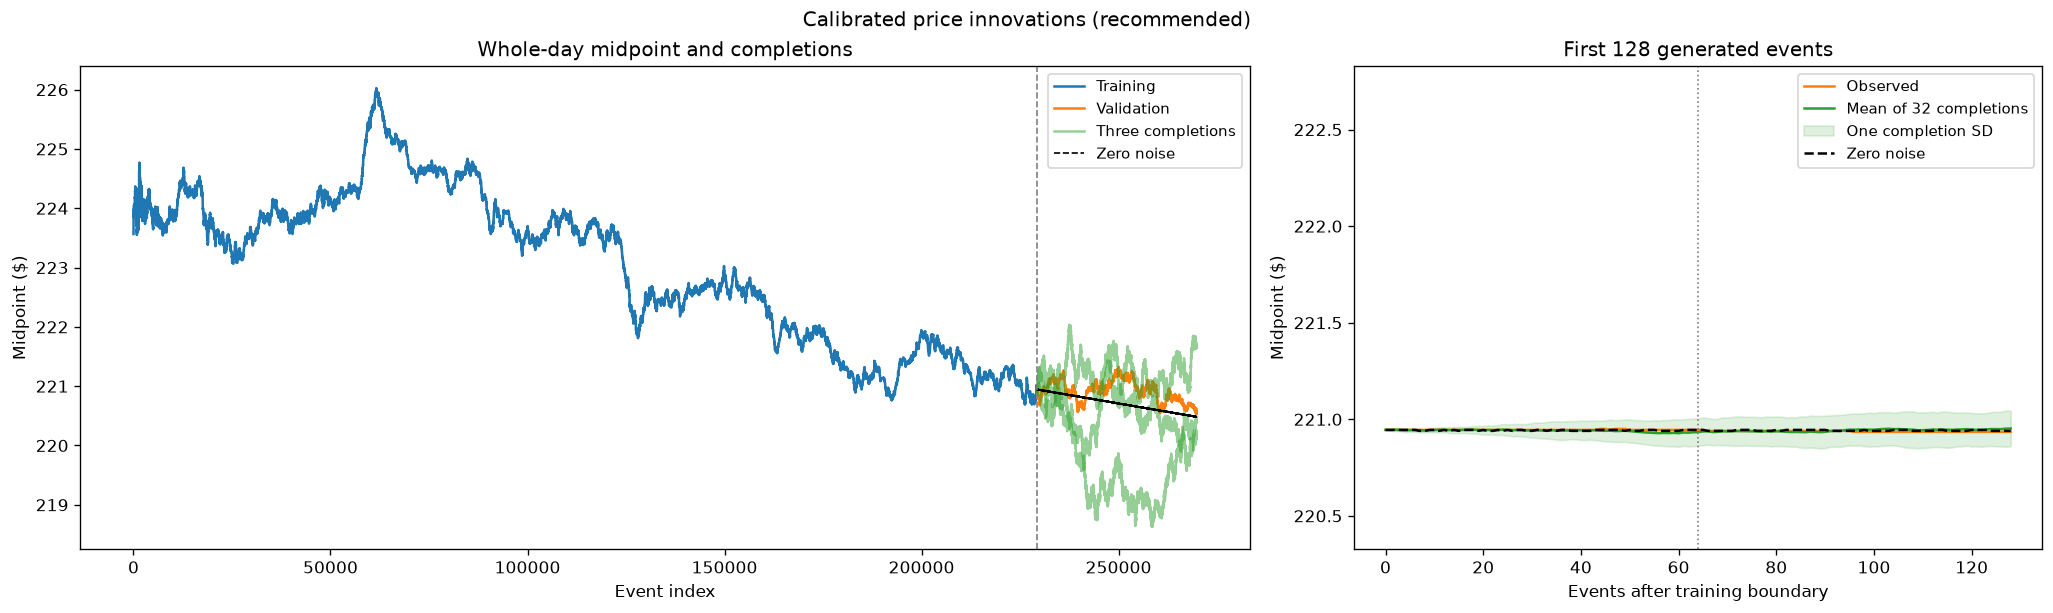

In [5]:
plot_experiment("innovation_head")


## Control: previous 16-event correction


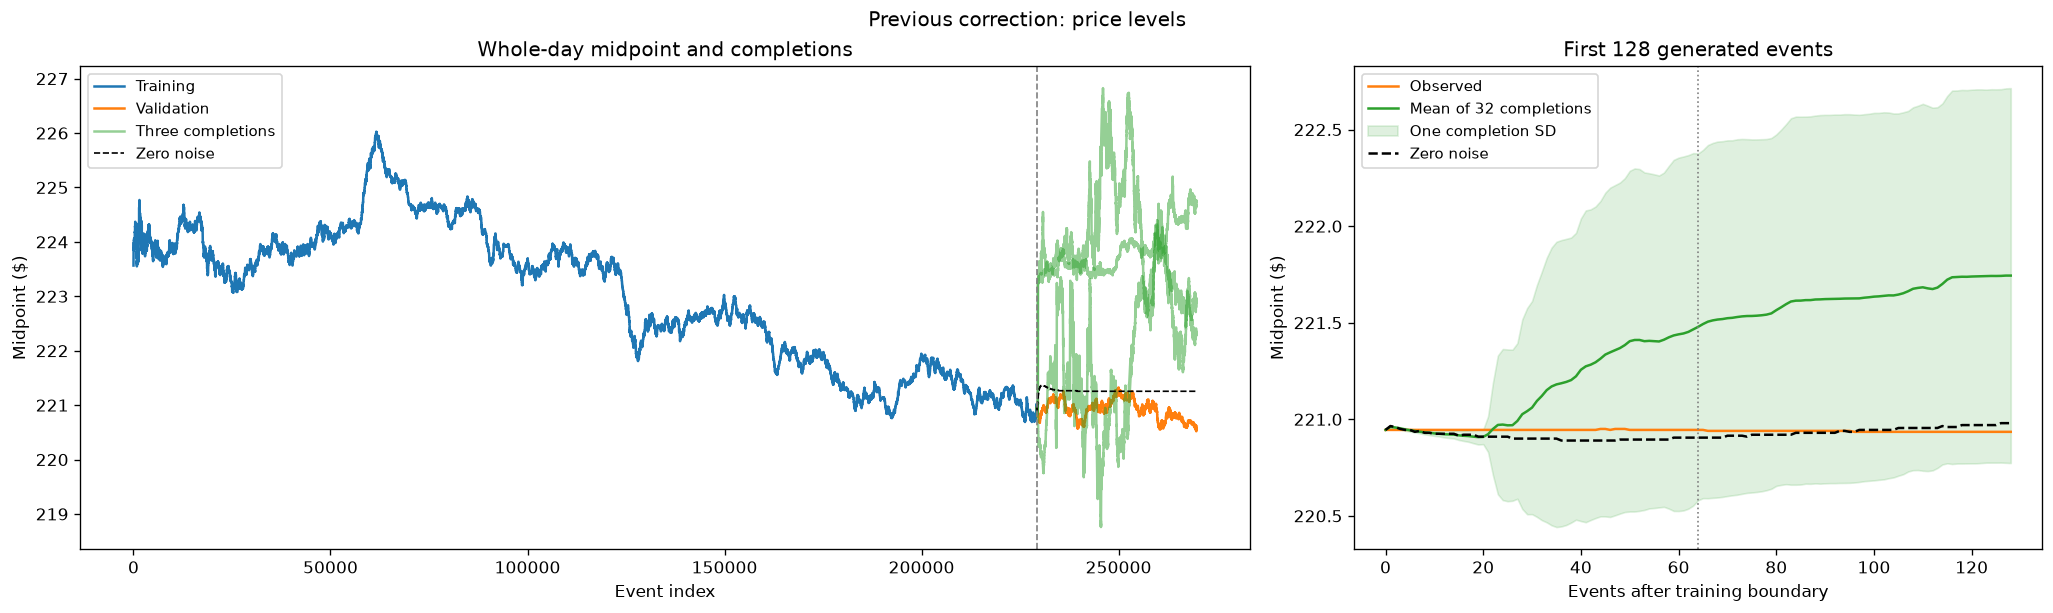

In [6]:
plot_experiment("previous_levels")


## Control: reset the Wiener clock alone


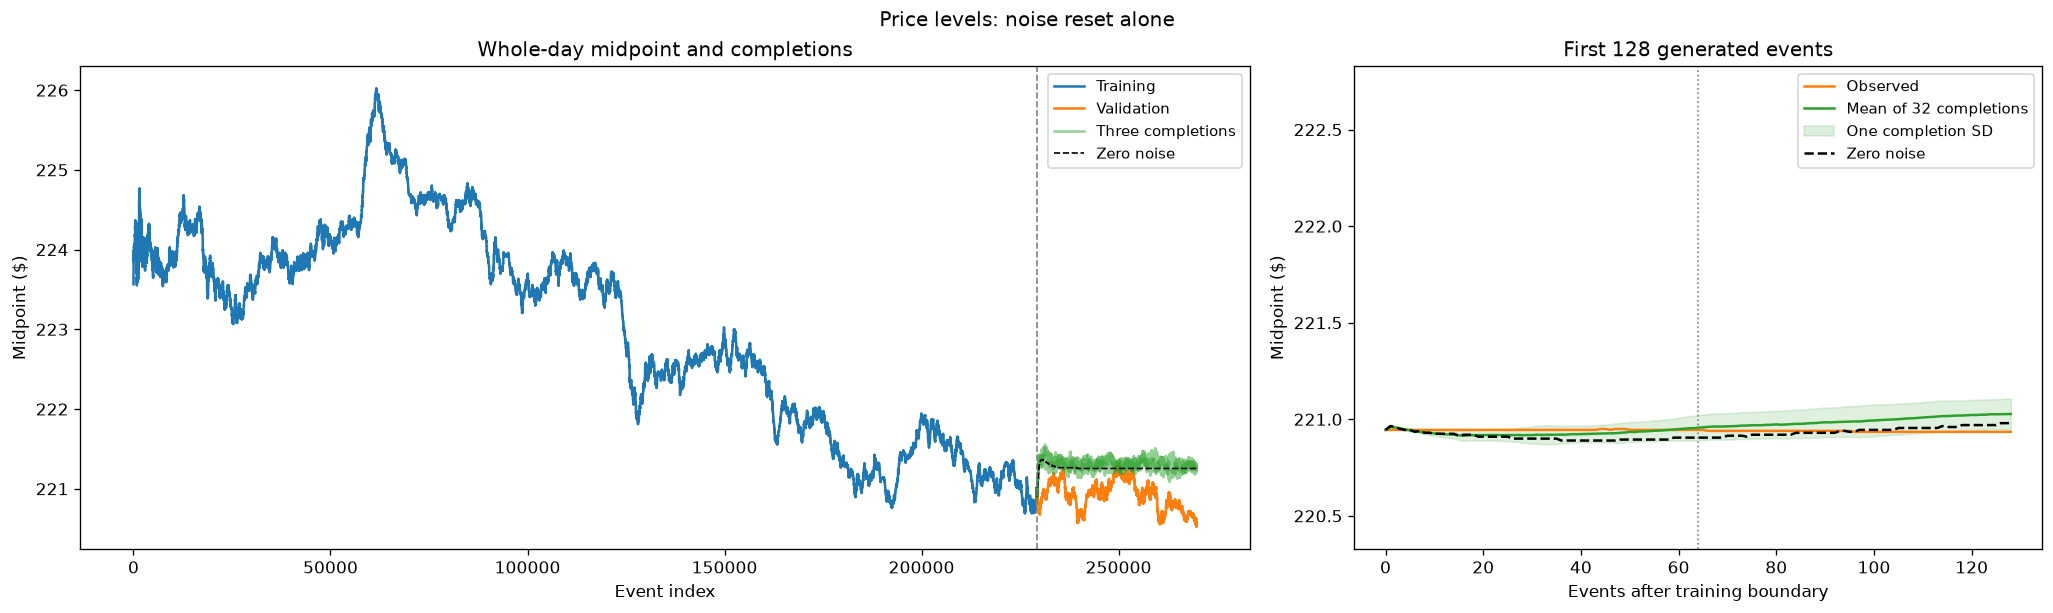

In [7]:
plot_experiment("reset_noise")


## Control: learned returns, context weight 1


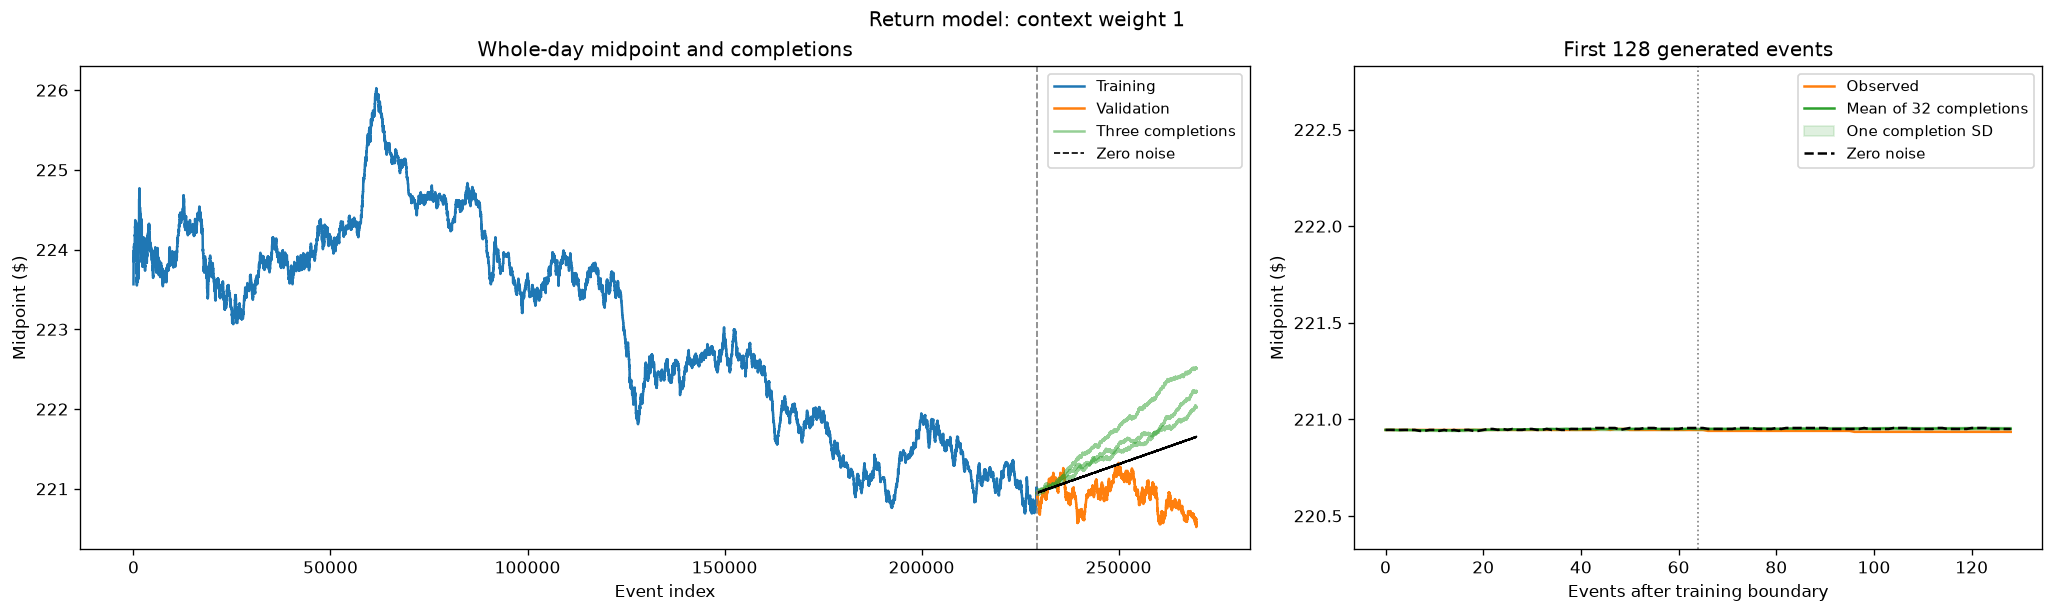

In [8]:
plot_experiment("returns_context_1_moments_10")


## Control: learned returns, context weight 10


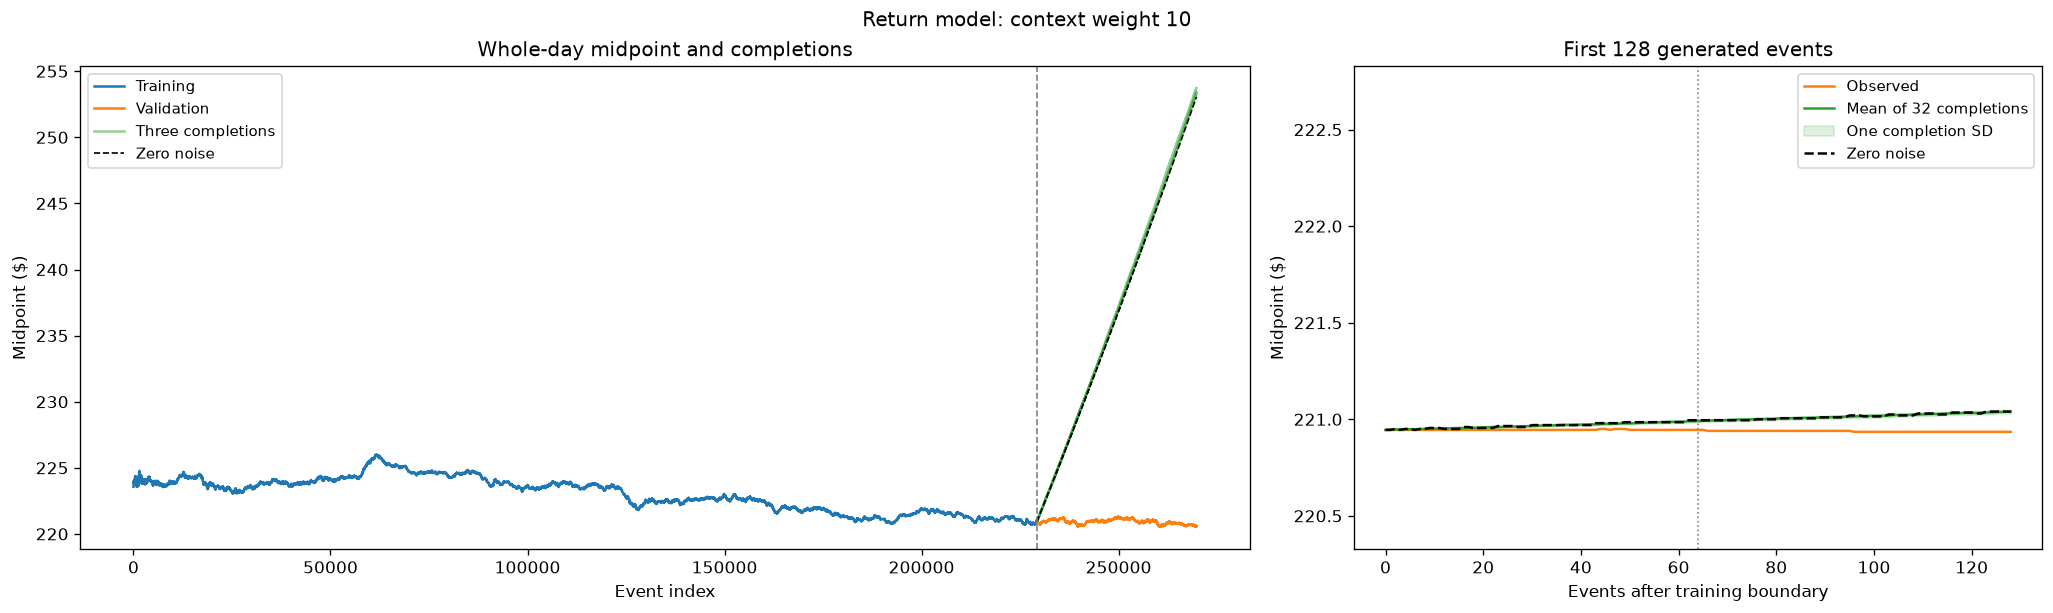

In [9]:
plot_experiment("returns_context_10_moments_10")


## Longer rollout: the first 1,024 events


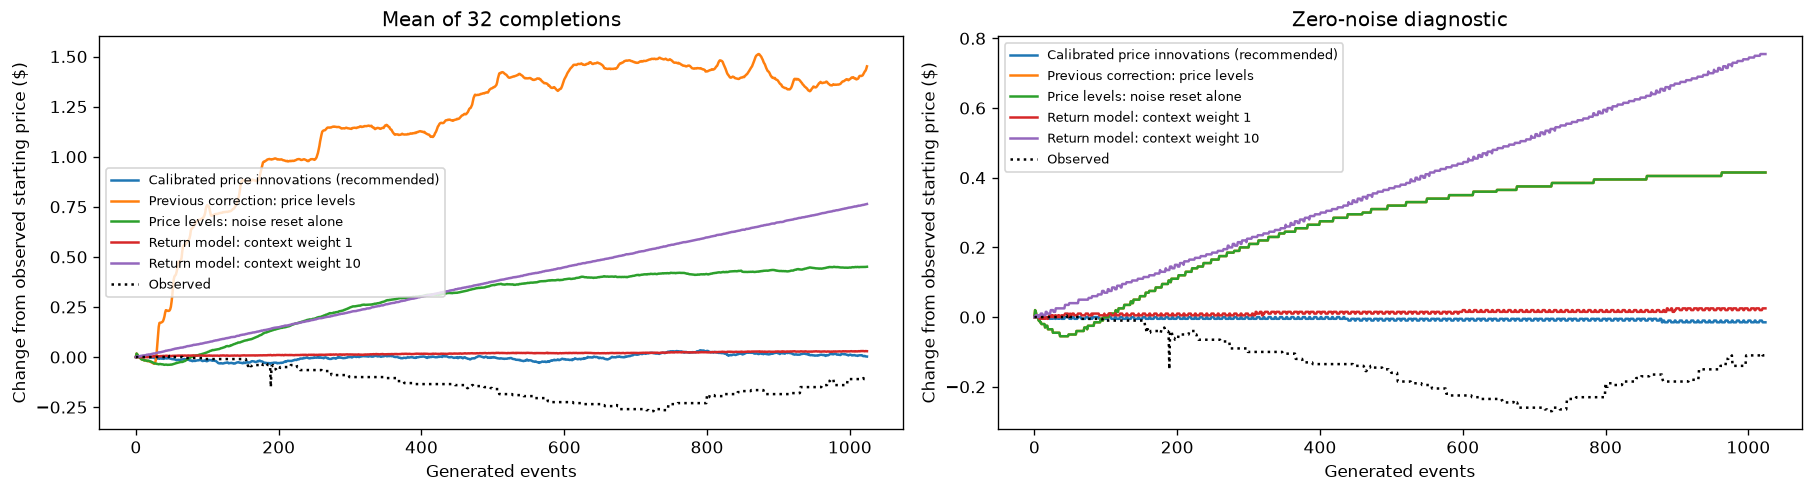

In [10]:
fig, axes=plt.subplots(1,2,figsize=(15,4),layout="constrained")
for name in EXPERIMENTS:
    long=json.loads((RESULTS_DIR/f"{name}_seed_0"/"long_boundary.json").read_text())
    start=long["starting_price_dollars"]
    events=np.arange(1025)
    axes[0].plot(events,np.r_[0,np.array(long["generated_mean"])-start],label=LABELS[name])
    axes[1].plot(events,np.r_[0,np.array(long["zero_noise"])-start],label=LABELS[name])
axes[0].plot(events,np.r_[0,np.array(long["observed"])-start],color="black",linestyle=":",label="Observed")
axes[1].plot(events,np.r_[0,np.array(long["observed"])-start],color="black",linestyle=":",label="Observed")
for ax,title in zip(axes,["Mean of 32 completions","Zero-noise diagnostic"]):
    ax.set(title=title,xlabel="Generated events",ylabel="Change from observed starting price ($)")
    ax.legend(fontsize=8)
fig.savefig(RESULTS_DIR/"figures"/"first_1024_events.png",dpi=140)
plt.show()


## Training duration

The innovation head is fitted after the return model's final checkpoint, so it
has one final diagnostic point. The return models' earlier checkpoints show
that learned drift can change sign during training.


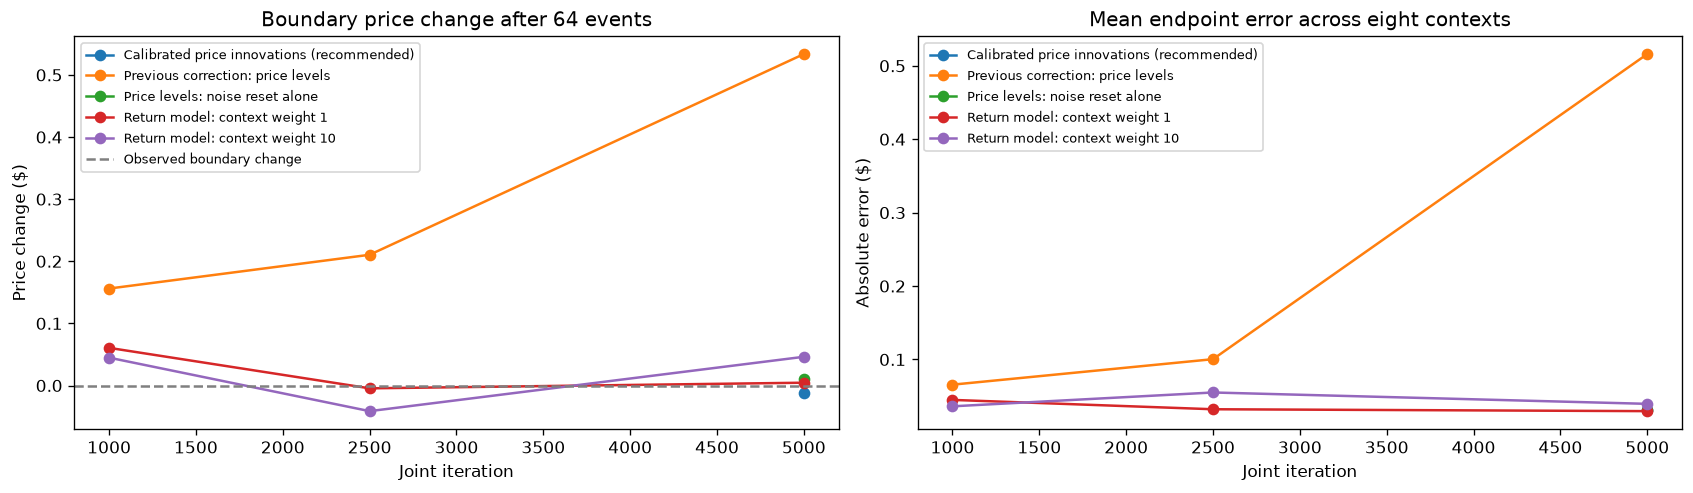

,context_reconstruction_mse,boundary_change_std_dollars,boundary_observed_change_std_dollars,last100_discriminator_loss,last100_generator_adversarial_loss
experiment,,,,,
Calibrated price innovations (recommended),0.000582,0.008563,0.00125,0.258455,4.086740
Previous correction: price levels,0.000534,0.072939,0.00125,0.477446,2.228884
Price levels: noise reset alone,0.000534,0.006037,0.00125,0.477446,2.228884
Return model: context weight 1,0.000582,0.003944,0.00125,0.258455,4.086740
Return model: context weight 10,0.000415,0.003545,0.00125,0.102902,5.373148


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), layout="constrained")
for name in EXPERIMENTS:
    rows = snapshots.loc[snapshots["experiment"] == LABELS[name]]
    axes[0].plot(rows["joint_step"], rows["boundary_64_event_change_dollars"],
                 marker="o", label=LABELS[name])
    axes[1].plot(rows["joint_step"], rows["context_mean_abs_64_event_error_dollars"],
                 marker="o", label=LABELS[name])
axes[0].axhline(observed_change, color="gray", linestyle="--", label="Observed boundary change")
axes[0].set(title="Boundary price change after 64 events", xlabel="Joint iteration",
            ylabel="Price change ($)")
axes[1].set(title="Mean endpoint error across eight contexts", xlabel="Joint iteration",
            ylabel="Absolute error ($)")
for ax in axes:
    ax.legend(fontsize=8)
fig.savefig(RESULTS_DIR / "figures" / "training_progress.png", dpi=140)
plt.show()

display(summary[[
    "context_reconstruction_mse", "boundary_change_std_dollars",
    "boundary_observed_change_std_dollars", "last100_discriminator_loss",
    "last100_generator_adversarial_loss",
]].round(6))


## Book features and price-change variation

These diagnostics use the same eight validation contexts and 32 completions
per context. The first feature is excluded from the book-feature error scores
because its representation differs between cases. Price-change SD is measured
in dollars after quote projection, including the first forecast step. The
observed SD is a descriptive comparison with the realized futures, not a
calibration test of the predictive distribution.


In [12]:
import torch
from dataclasses import asdict, is_dataclass
from evaluation import compare_sequences
from predict import load_checkpoint
from training_balance_experiment import complete, noise_paths

torch.set_num_threads(1)
quality_rows=[]
for name in EXPERIMENTS:
    directory=RESULTS_DIR/f"{name}_seed_0"
    model, checkpoint=load_checkpoint(directory/"model.pt")
    representation=checkpoint.get("price_representation","level")
    train_data=LOBSTERLevel10Dataset(True,price_representation=representation)
    val_data=LOBSTERLevel10Dataset(False,price_representation=representation)
    features=torch.cat((train_data.features,val_data.features))
    prices=np.r_[midpoint(train_data.books),midpoint(val_data.books)]
    ends=results[name]["contexts"]["context_event"].to_numpy(dtype=int)
    context=torch.stack([features[end-64:end] for end in ends]).repeat_interleave(32,dim=0)
    paths=noise_paths(len(context),128,model,64)
    if name=="reset_noise":
        steps=torch.arange(paths.shape[1])
        starts=((steps-1).clamp_min(0)//16)*16
        paths=paths-paths[:,starts]
    generated=complete(model,context,paths)
    actual=torch.stack([features[end:end+128] for end in ends]).repeat_interleave(32,dim=0)
    comparison=compare_sequences(actual[...,1:],generated[...,1:])
    if is_dataclass(comparison): comparison=asdict(comparison)
    errors=comparison["absolute_errors"]
    anchors=np.repeat(prices[ends-1],32)
    projected=np.stack([midpoint(train_data.feature_sequence_to_df(sequence,initial_midpoint=anchor*10000))
                        for sequence,anchor in zip(generated,anchors)])
    fake_changes=np.diff(np.column_stack((anchors,projected)),axis=1)
    observed=np.stack([prices[end:end+128] for end in ends])
    real_changes=np.diff(np.column_stack((prices[ends-1],observed)),axis=1)
    quality_rows.append({"model":LABELS[name],"other39_mean_error":float(errors["mean"]),
        "other39_std_error":float(errors["std"]),"generated_price_change_sd_dollars":fake_changes.std(),
        "observed_price_change_sd_dollars":real_changes.std(),
        "price_change_sd_ratio":fake_changes.std()/real_changes.std()})
quality=pd.DataFrame(quality_rows).set_index("model")
quality.to_csv(RESULTS_DIR/"book_quality.csv")
display(quality.round(6))


,other39_mean_error,other39_std_error,generated_price_change_sd_dollars,observed_price_change_sd_dollars,price_change_sd_ratio
model,,,,,
Calibrated price innovations (recommended),0.673076,0.516725,0.008977,0.004528,1.982423
Previous correction: price levels,0.856588,0.300095,0.059169,0.004528,13.065943
Price levels: noise reset alone,1.121596,0.258263,0.005535,0.004528,1.222343
Return model: context weight 1,0.673245,0.516765,0.003948,0.004528,0.871873
Return model: context weight 10,0.796537,0.579229,0.003371,0.004528,0.744322


## Measured outcome

The innovation head removes the systematic learned price-level reset. It fixes
conditional expected arithmetic-price drift to the empirical training drift;
individual noisy paths can still rise or fall. That assumption is explicit and
is not evidence that the original GAN learned accurate directional returns.
The book-structure generator and the conditional uncertainty still need broader
validation.


In [13]:
from IPython.display import Markdown
row=summary.loc[LABELS["innovation_head"]]
old=summary.loc[LABELS["previous_levels"]]
lines=[f"The recommended model's mean 64-event change is **{row['boundary_64_event_change_dollars']:+.4f} dollars**, versus **{old['boundary_64_event_change_dollars']:+.4f}** for the previous correction.",
       f"At 1,024 events its mean change is **{row['boundary_1024_event_change_dollars']:+.4f} dollars**, versus **{old['boundary_1024_event_change_dollars']:+.4f}**. Its zero-noise change is **{row['boundary_zero_noise_1024_event_change_dollars']:+.4f} dollars**.",
       f"Its 64-event endpoint SD is **${row['boundary_64_event_std_dollars']:.4f}**, versus **${old['boundary_64_event_std_dollars']:.4f}**. Average endpoint error across eight contexts is **${row['context_mean_abs_64_event_error_dollars']:.4f}**.",
       "The full-validation noisy paths retain random price movements; expected drift is determined by training data rather than a neural attraction to an absolute price level."]
display(Markdown("\n\n".join(lines)))
(RESULTS_DIR/"summary.md").write_text("\n\n".join(lines)+"\n")


The recommended model's mean 64-event change is **-0.0117 dollars**, versus **+0.5336** for the previous correction.

At 1,024 events its mean change is **+0.0025 dollars**, versus **+1.4509**. Its zero-noise change is **-0.0150 dollars**.

Its 64-event endpoint SD is **$0.0705**, versus **$0.8980**. Average endpoint error across eight contexts is **$0.0313**.

The full-validation noisy paths retain random price movements; expected drift is determined by training data rather than a neural attraction to an absolute price level.